<a href="https://colab.research.google.com/github/vcardui/RealTimeCharacterDetection/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
# +----------------------------------------------------------------------------+
# | CARDUI TECH v1.0.0
# +----------------------------------------------------------------------------+
# | Copyright (c) 2026 - 2026, CARDUITECH.COM (www.carduitech.com)
# | Vanessa Reteguín <vanessa@reteguin.com>
# | Released under the MIT license
# | www.carduitech.com/license/
# +----------------------------------------------------------------------------+
# | Author.......: Vanessa Reteguín <vanessa@reteguin.com>
# | First release: September 16th, 2026
# | Last update..: September 16th, 2026
# | Course.......: Automatons II
# | WhatIs.......: Real Time Character Detection - Main
# +----------------------------------------------------------------------------++
# ------------------------- Instructions -----------------------
# Instrucciones: crea una CNN para clasificar caracteres (conjunto de datos
# "mnist" o "emnist"). Utiliza la red para detectar caracteres en tiempo real.

# ---

# - Detection de caracteres en tiempo real
# - Palabra por palabra vs carácter a carácter

#    Hola = hola = hola.

# - Justificar uso de modelo: Transformer? CNN? Otra?
# - Conclusiones
# - *Entrenar por partes -> Check points

# ------------ Resources / Documentation involved -------------
# MNIST Dataset: https://www.kaggle.com/datasets/hojjatk/mnist-dataset

# Deep learning on MNIST: https://numpy.org/numpy-tutorials/tutorial-deep-learning-on-mnist/

# MNIST Dataset in Python: Complete Guide with Examples:
# https://www.digitalocean.com/community/tutorials/mnist-dataset-in-python$0

# 1. Authenticate with Kaggle API to download datasets

In [74]:
"""
!pip install kaggle -q

from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(name=fn, length=len(uploaded[fn])))

!rm -rf ~/.kaggle
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle/kaggle.json
"""

'\n!pip install kaggle -q\n\nfrom google.colab import files\n\nuploaded = files.upload()\n\nfor fn in uploaded.keys():\n  print(\'User uploaded file "{name}" with length {length} bytes\'.format(name=fn, length=len(uploaded[fn])))\n\n!rm -rf ~/.kaggle\n!mkdir -p ~/.kaggle\n!mv kaggle.json ~/.kaggle/kaggle.json\n!chmod 600 ~/.kaggle/kaggle.json\n!ls ~/.kaggle/kaggle.json\n'

In [75]:
# ------------------------- Libraries -------------------------
import kagglehub # kagglehub.dataset_download(DATASET_ID)

import os  # os.path.exists(path)

import cv2 # camera

import numpy as np
import matplotlib.pyplot as plt

from sklearn import metrics

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten

In [79]:
# ------------------------- Variables -------------------------
# DATASET_FOLDER = 'input/mnist-dataset/'
DATASET_ID = 'hojjatk/mnist-dataset'

data_sources = {
    "training_images": "train-images-idx3-ubyte",  # 60,000 training images.
    "test_images": "t10k-images-idx3-ubyte",  # 10,000 test images.
    "training_labels": "train-labels-idx1-ubyte",  # 60,000 training labels.
    "test_labels": "t10k-labels-idx1-ubyte",  # 10,000 test labels.
}

In [81]:

DATASET_FOLDER = kagglehub.dataset_download(DATASET_ID)
print(DATASET_FOLDER)

Using Colab cache for faster access to the 'mnist-dataset' dataset.
/kaggle/input/mnist-dataset


Save images and labels into mnist_dataset dictionary as 1D arrays (neural network will expect a 1D array)

Since each image is 28 x 28 pixels, each file is reshaped into a 1 x 784 array

rb = raw binary

In [82]:
mnist_dataset = {}

for key in ("training_images", "test_images"):
    with open(os.path.join(DATASET_FOLDER, f'{data_sources[key]}/{data_sources[key]}'), "rb") as mnist_file:
         # mnist_dataset[key] = np.frombuffer(mnist_file.read(), np.uint8, offset=16).reshape(-1, 28 * 28)
         mnist_dataset[key] = np.frombuffer(mnist_file.read(), np.uint8, offset=16).reshape(-1, 28, 28)

for key in ("training_labels", "test_labels"):
    with open(os.path.join(DATASET_FOLDER, f'{data_sources[key]}/{data_sources[key]}'), "rb") as mnist_file:
        mnist_dataset[key] = np.frombuffer(mnist_file.read(), np.uint8, offset=8)

Split dataset into training and set test

In [83]:
x_train, y_train, x_test, y_test = (
    mnist_dataset["training_images"],
    mnist_dataset["training_labels"],
    mnist_dataset["test_images"],
    mnist_dataset["test_labels"],
)

print(f"""Dataset shapes:
training_images (x_train): {x_train.shape}
training_labels (y_train): {y_train.shape}

test_images (x_test): {x_test.shape}
test_labels (y_test): {y_test.shape}
""")

Dataset shapes:
training_images (x_train): (60000, 28, 28)
training_labels (y_train): (60000,)

test_images (x_test): (10000, 28, 28)
test_labels (y_test): (10000,)



Output:

X (60000, 784) -> (60000 rows, 1 x 784) -> 1D

√ (60000, 28, 28) -> (60000 rows, 28 x 28) -> 2D

Tomar 4 imágenes aleatorias
Pasar de vector 1D (784, ) a 2D (28, 28) -> Poder mostrar imagen 2D

Mostrar imagen en escala de grises

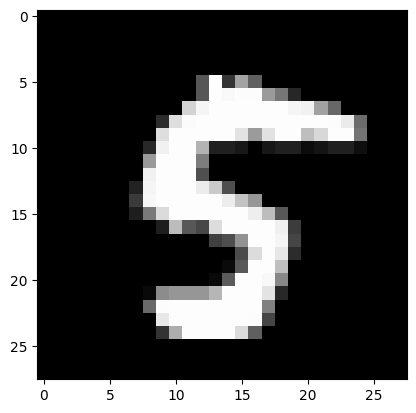

In [84]:
rand = np.random.default_rng().integers(low=0, high=59999, size=1)
mnist_image = x_train[rand, :].reshape(28, 28)

fig, ax = plt.subplots()
ax.imshow(mnist_image, cmap="gray")


# 2. Pre-process the data

## Scaling
Normalize the image's data

8-bit integers [0, 255] -> floating-point [0, 1] interval divided by 255

In [85]:
print('Data type of:\n* Training images: {training_images}\n* Test images: {test_images}'.format(training_images=x_train.dtype, test_images=x_test.dtype))

Data type of:
* Training images: uint8
* Test images: uint8


In [87]:
training_sample = 42000
test_sample = 18000

training_images = x_train[0:training_sample] / 255
test_images = x_test[0:test_sample] / 255

In [88]:
print('Data type of:\n* Training images: {training_images}\n* Test images: {test_images}'.format(training_images=training_images.dtype, test_images=test_images.dtype))

# print(f"Original image: {x_train[0]}\nTraining image: {training_images[0]}")

Data type of:
* Training images: float64
* Test images: float64


## One-hot encoding
Transform floating point class labels into binary vector

Create 10D all-zero vector (number labels 0 to 9)

In [89]:
print('Data type of: \n* Training labels: {training_labels}\n* Test labels: {test_labels}'.format(training_labels=y_train.dtype, test_labels=y_test.dtype))

Data type of: 
* Training labels: uint8
* Test labels: uint8


In [90]:
def one_hot_encoding(labels, dimension=10):
    one_hot_labels = labels[..., None] == np.arange(dimension)[None]

    return one_hot_labels.astype(np.float64)

In [91]:
training_labels = one_hot_encoding(y_train[:training_sample])
test_labels = one_hot_encoding(y_test[:test_sample])

In [92]:
print('Data type of: \n* Training labels: {training_labels}\n* Test labels: {test_labels}'.format(training_labels=training_labels.dtype, test_labels=test_labels.dtype))

print("\nOrginals vs Training labels")
for i in range(0, 3):
  print(f"    {y_train[i]}       {training_labels[i]}")

Data type of: 
* Training labels: float64
* Test labels: float64

Orginals vs Training labels
    5       [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
    0       [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
    4       [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


In [93]:
print(f"""Dataset shapes:
training_images (x_train): {x_train.shape}
training_labels (y_train): {y_train.shape}

test_images (x_test): {x_test.shape}
test_labels (y_test): {y_test.shape}
""")

Dataset shapes:
training_images (x_train): (60000, 28, 28)
training_labels (y_train): (60000,)

test_images (x_test): (10000, 28, 28)
test_labels (y_test): (10000,)



# Crear modelo

In [94]:
model = models.Sequential([
    layers.Reshape((28, 28, 1), input_shape=(28, 28, 1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_3 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,890 (511.29 KB)

 Trainable params: 130,890 (511.29 KB)

 Non-trainable params: 0 (0.00 B)

In [95]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training model...")

model.fit(training_images, training_labels, epochs=10, validation_data=(test_images, test_labels))

Training model...
Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9206 - loss: 0.2508 - val_accuracy: 0.9812 - val_loss: 0.0571
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9783 - loss: 0.0761 - val_accuracy: 0.9854 - val_loss: 0.0461
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9837 - loss: 0.0553 - val_accuracy: 0.9884 - val_loss: 0.0380
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9869 - loss: 0.0455 - val_accuracy: 0.9909 - val_loss: 0.0284
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9893 - loss: 0.0363 - val_accuracy: 0.9900 - val_loss: 0.0299
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9907 - loss: 0.0298 - val_accuracy: 0.9907 - val_loss: 0.0313
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9910 - loss: 0.0282 - val_accuracy: 0.9918 - val_loss: 0.0298
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.99

In [96]:
model.save('cardui_mnist_cnn.keras')
print("Model saved successfully as: cardui_mnist_cnn.keras")

Model saved successfully as: cardui_mnist_cnn.keras


1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


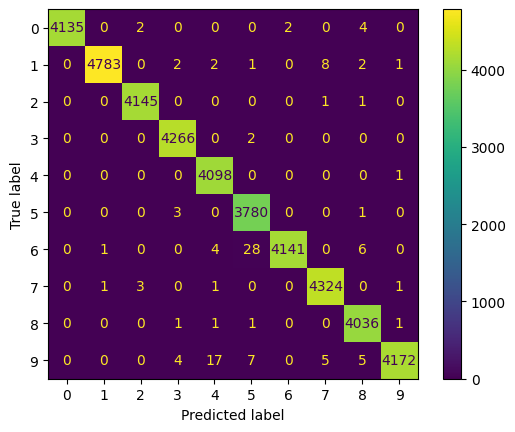

In [97]:
def confusion_matrix(training_images, training_labels):
    labels_prediction = model.predict(training_images)
    labels_prediction_classes = np.argmax(labels_prediction, axis=1)

    if training_labels.ndim > 1:
        true_labels_classes = np.argmax(training_labels, axis=1)
    else:
        true_labels_classes = training_labels

    cm = metrics.confusion_matrix(true_labels_classes, labels_prediction_classes)
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
    cm_display.plot()

confusion_matrix(training_images, training_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9900 - loss: 0.0337
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


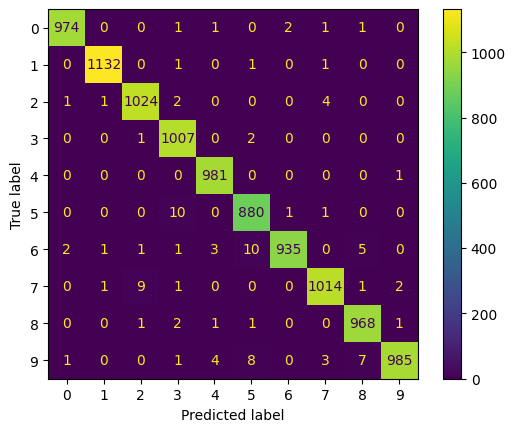

In [98]:
model.evaluate(test_images, test_labels)
confusion_matrix(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


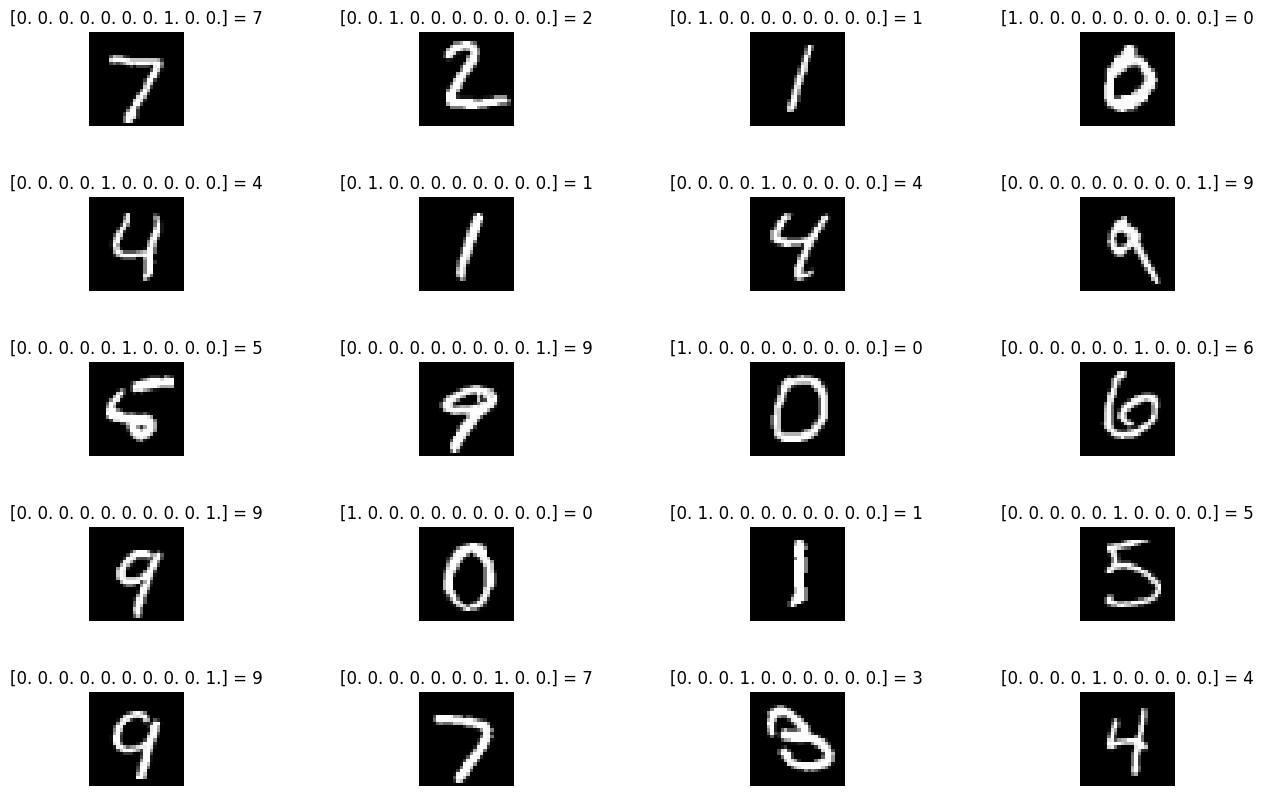

In [99]:
labels_prediciton = np.argmax(model.predict(test_images), axis = 1)
y = [f'{test_labels[i]} = {labels_prediciton[i]}' for i in range(test_labels.shape[0])]
# y = [f'{labels_prediciton[i]}' for i in range(test_labels.shape[0])]

# fig, axes = plt.subplots(5, 3)
cols = 4
rows = 5

fig, axes = plt.subplots(rows, cols, figsize=(14, 10))
fig.subplots_adjust(wspace=2.5, hspace=0.5)


for i in range(rows * cols):
    ax = axes[i // cols, i % cols]

    ax.imshow(test_images[i], cmap = 'gray')
    ax.set_title(y[i], fontsize=12)
    ax.axis('off')

# Recognize characters via camera

In [100]:
import cv2
import numpy as np
import tensorflow as tf

model = tf.keras.models.load_model("cardui_mnist_cnn-2.keras")
cap = cv2.VideoCapture(1) # id for default webcam = 0

# cap.set(3, 640) # width=640, id=3 for width
# cap.set(4, 480) # height=480, id=4 for height
cap.set(10, 100) # brightness=100, id=10 for brightness

if not cap.isOpened():
    print ("[!] No se pudo abrir la webcam")
else:
    print("La webcam se abrió correctamente. Presiona 'q' para salir.")

while True:
    success, img = cap.read()

    if not success:
        print("[!] No se pudo capturar el fotograma")
        break

    cv2.imshow('Output', img)

    gray_frame = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # Escala de grises
    resized_frame = cv2.resize(gray_frame, (28, 28), interpolation=cv2. INTER_AREA) # Tamaño MNIST
    cv2.imshow('resized_frame', resized_frame)

    normalized_frame = resized_frame.astype('float32') / 255.0 # Normalizar para modelo: 0-255 ->  0-1
    input_image = np.expand_dims(normalized_frame, axis=-1) # Añadir dimensión de canal
    input_image = np.expand_dims(input_image, axis=0) # Añadir dimensión de lote
    # cv2.imshow('input_image', input_image)

    # Predicción
    predictions = model.predict(input_image)
    predicted_class = np.argmax(predictions[0])
    print(predicted_class)

    # Mostrar frame original + predicción
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText (img, f'Prediction: {predicted_class}', org=(10, 70), fontFace=font, fontScale=3, color=(0, 255, 0), thickness=2, lineType=cv2.LINE_AA)
    cv2.imshow('Real-time Number Detection', img)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        cap.release()
        cv2.destroyAllWindows()
        break

cap.release()
cv2.destroyAllWindows()

print ("[*] Transmisión de webcam concluida")

ValueError: File not found: filepath=cardui_mnist_cnn-2.keras. Please ensure the file is an accessible `.keras` zip file.

In [101]:
!jupyter nbconvert --to html --output-dir="./" "main.ipynb"

[NbConvertApp] Converting notebook main.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 479370 bytes to main.html
